In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/transient2_kOmegaSST_2/yvsUy.csv'
sim_df = pd.read_csv(sim_file)
sim_df = sim_df[['Points:1', '(U_stddev:2/U_stddev:1)']].apply(pd.to_numeric, errors='coerce').dropna()
sim_df['Points:1'] = (sim_df['Points:1'] ) / 0.04              #+ 0.188453-0.2
sim_df['(U_stddev:2/U_stddev:1)'] = sim_df['(U_stddev:2/U_stddev:1)'] / 1
sim_df.to_csv('/home/d/ssh_files/transient2_kOmegaSST_2/d_yvsUy.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_anisotropy_y', 'r1_anisotropy_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_anisotropy_x']
mvp_y = mvp_df['r1_anisotropy_y']

# --- Experimental data (already normalized) ---
exp_raw = [
    (-0.0177, 0.0926), (-0.1337, 0.1941), (-0.2925, 0.307), (-0.396, 0.4007), (-0.4213, 0.4992),
    (-0.6139, 0.6355), (-0.6357, 0.7497), (-0.5916, 0.8765), (-0.4923, 1.0038), (-0.288, 1.136),
    (-0.0659, 1.2646), (0.0298, 1.3919), (0.1291, 1.5152), (0.1643, 1.6499), (0.2902, 1.7814),
    (0.3735, 1.9005), (0.398, 2.0312), (0.5205, 2.1548), (0.5272, 2.2772), (0.6069, 2.3963),
    (0.6368, 2.527), (0.7179, 2.7726), (0.7206, 3.0253), (0.7964, 3.2708), (0.8027, 3.5234),
    (0.8232, 3.7724), (0.9679, 5.2938), (0.968, 5.807), (0.9752, 6.3085), (1.0058, 6.8141),
    (1.006, 7.2997), (0.9884, 7.797), (1.0046, 8.2946), (1.0119, 8.7921), (0.9889, 9.2852), (0.9927, 9.7867)
]
exp_x, exp_y = zip(*[(y, u) for u, y in exp_raw])

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST
plt.plot(sim_df['Points:1'], sim_df['(U_stddev:2/U_stddev:1)'], 's-', color='red', label='kOmegaSST', zorder=2)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='experimental')

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1)

# Labels and grid
plt.xlabel('y / 0.04')
plt.ylabel('u_y / 16.6')
plt.title('y/0.04 and u_y/16.6 Comparison')

plt.xlim(0, 10)
plt.ylim(-1, 1.5)
plt.xticks(np.arange(0, 11, 2))
plt.yticks(np.arange(-1, 1.6, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=3)
plt.legend()
plt.tight_layout()
plt.show()


KeyError: "['(U_stddev:2/U_stddev:1)'] not in index"

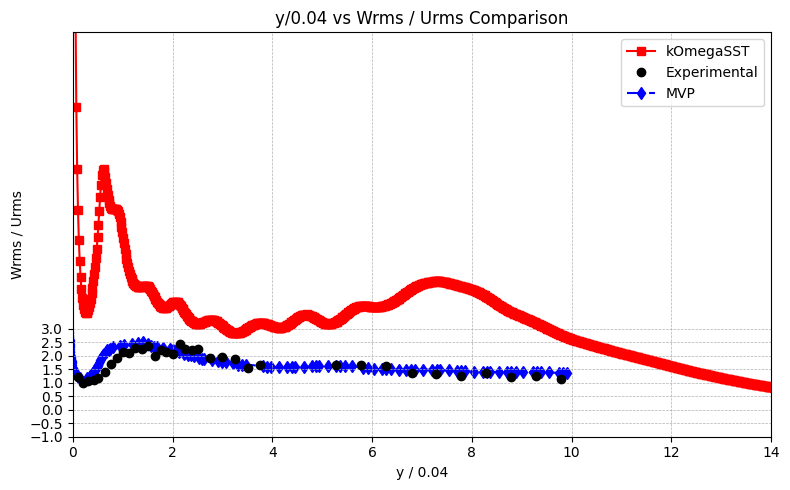

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/transient2_kOmegaSST_2/yvsUy.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'U_stddev:2', 'U_stddev:1', 'U_stddev:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Normalize y
sim_df['Points:1'] = (sim_df['Points:1']-0.011547) / 0.04


# Compute ratio: Wrms / Urms = U_stddev:2 / sqrt(Ux^2 + Uy^2 + Uz^2)
sim_df['Urms_mag'] = np.sqrt(sim_df['U_stddev:0']**2 + sim_df['U_stddev:1']**2 + sim_df['U_stddev:2']**2)
sim_df['ratio'] = sim_df['U_stddev:2'] / sim_df['U_stddev:1']

# Save processed data
sim_df[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/transient2_kOmegaSST_2/d_yvsUy.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_anisotropy_y', 'r1_anisotropy_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_anisotropy_x']
mvp_y = mvp_df['r1_anisotropy_y']

# --- Updated Experimental data (inverted from (u_y, y) to (y, u_y)) ---
exp_raw = [
    (1.2139, 0.1078), (1.0038, 0.194), (1.0645, 0.3017), (1.1037, 0.4138), (1.1684, 0.5043),
    (1.3999, 0.6336), (1.7001, 0.7543), (1.9237, 0.875), (2.1376, 1.0), (2.0884, 1.1336),
    (2.2826, 1.25), (2.2433, 1.3836), (2.3551, 1.5043), (2.0036, 1.6379), (2.2194, 1.7586),
    (2.1447, 1.875), (2.0603, 2.0043), (2.435, 2.1379), (2.2485, 2.25), (2.213, 2.3793),
    (2.264, 2.5086), (1.9282, 2.75), (1.9535, 2.9957), (1.8982, 3.2457), (1.5566, 3.5043),
    (1.6564, 3.75), (1.6593, 5.2671), (1.6726, 5.7671), (1.6231, 6.2845), (1.3735, 6.7888),
    (1.3436, 7.2845), (1.2628, 7.7759), (1.3546, 8.2759), (1.211, 8.7888), (1.2361, 9.2802),
    (1.1513, 9.7888)
]
exp_x, exp_y = zip(*[(y, u) for u, y in exp_raw])  # Invert (u_y, y) → (y, u_y)

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST
plt.plot(sim_df['Points:1'], sim_df['ratio'], 's-', color='red', label='kOmegaSST', zorder=2)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1)

# Labels and grid
plt.xlabel('y / 0.04')
plt.ylabel('Wrms / Urms')
plt.title('y/0.04 vs Wrms / Urms Comparison')

plt.xlim(0, 10)
plt.ylim(0, 14)
plt.xticks(np.arange(0, 15, 2))
plt.yticks(np.arange(-1, 3.1, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()


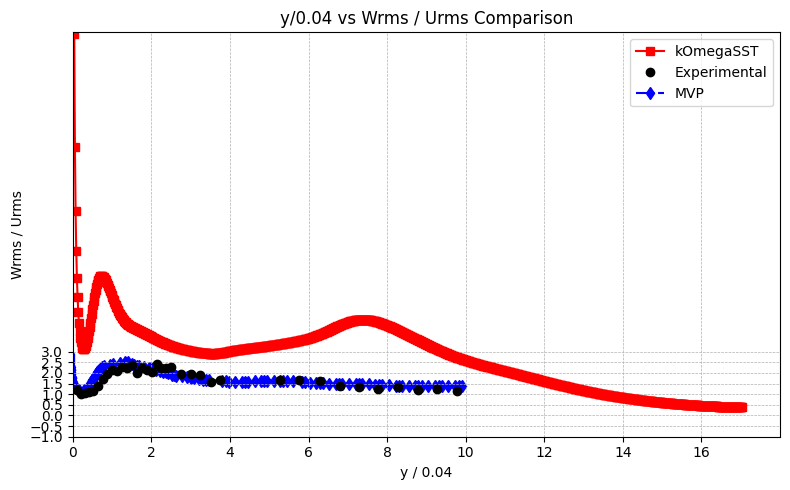

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/rms7_15/line.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'UPrime2Mean:2', 'UPrime2Mean:1', 'UPrime2Mean:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Normalize y
sim_df['Points:1'] = (sim_df['Points:1']-0.011547) / 0.04


# Compute ratio: Wrms / Urms = U_stddev:2 / sqrt(Ux^2 + Uy^2 + Uz^2)
#sim_df['Urms_mag'] = np.sqrt(sim_df['UPrime2Mean:0']**2 + sim_df['UPrime2Mean:1']**2 + sim_df['UPrime2Mean:2']**2)
#sim_df['ratio'] = sim_df['UPrime2Mean:2'] / sim_df['UPrime2Mean:1']
sim_df['ratio'] = np.sqrt(sim_df['UPrime2Mean:2'] / sim_df['UPrime2Mean:1'])

# Save processed data
sim_df[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/rms7_15/d_line.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_anisotropy_y', 'r1_anisotropy_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_anisotropy_x']
mvp_y = mvp_df['r1_anisotropy_y']

# --- Updated Experimental data (inverted from (u_y, y) to (y, u_y)) ---
exp_raw = [
    (1.2139, 0.1078), (1.0038, 0.194), (1.0645, 0.3017), (1.1037, 0.4138), (1.1684, 0.5043),
    (1.3999, 0.6336), (1.7001, 0.7543), (1.9237, 0.875), (2.1376, 1.0), (2.0884, 1.1336),
    (2.2826, 1.25), (2.2433, 1.3836), (2.3551, 1.5043), (2.0036, 1.6379), (2.2194, 1.7586),
    (2.1447, 1.875), (2.0603, 2.0043), (2.435, 2.1379), (2.2485, 2.25), (2.213, 2.3793),
    (2.264, 2.5086), (1.9282, 2.75), (1.9535, 2.9957), (1.8982, 3.2457), (1.5566, 3.5043),
    (1.6564, 3.75), (1.6593, 5.2671), (1.6726, 5.7671), (1.6231, 6.2845), (1.3735, 6.7888),
    (1.3436, 7.2845), (1.2628, 7.7759), (1.3546, 8.2759), (1.211, 8.7888), (1.2361, 9.2802),
    (1.1513, 9.7888)
]
exp_x, exp_y = zip(*[(y, u) for u, y in exp_raw])  # Invert (u_y, y) → (y, u_y)

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST
plt.plot(sim_df['Points:1'], sim_df['ratio'], 's-', color='red', label='kOmegaSST', zorder=2)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1)

# Labels and grid
plt.xlabel('y / 0.04')
plt.ylabel('Wrms / Urms')
plt.title('y/0.04 vs Wrms / Urms Comparison')

plt.xlim(0, 18)
plt.ylim(0, 18)
plt.xticks(np.arange(0, 18, 2))
plt.yticks(np.arange(-1, 3.1, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()


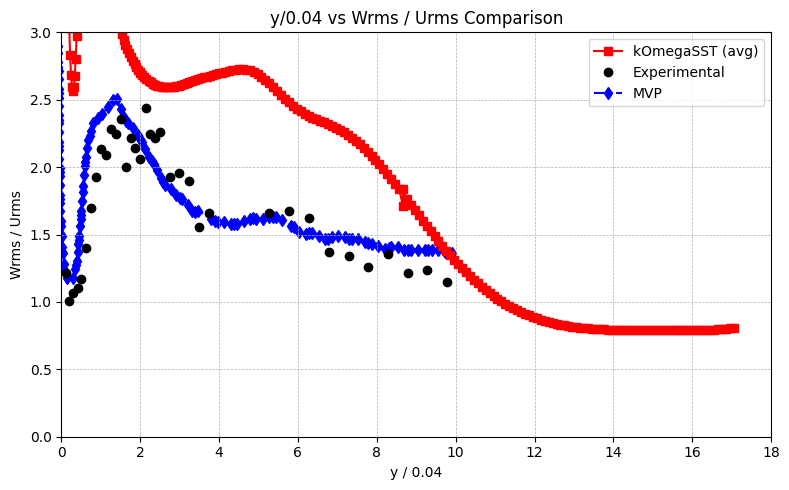

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and Process kOmegaSST (simulated) ---
sim_file = '/home/d/ssh_files/rms7_15/plane.csv'
sim_df = pd.read_csv(sim_file)

# Convert relevant columns to numeric
sim_df = sim_df[['Points:1', 'UPrime2Mean:2', 'UPrime2Mean:1', 'UPrime2Mean:0']].apply(pd.to_numeric, errors='coerce').dropna()

# Group by 'Points:1' (y-location) and average all other columns
grouped = sim_df.groupby('Points:1').mean().reset_index()

# Normalize y
grouped['Points:1'] = (grouped['Points:1'] - 0.011547) / 0.04

# Compute ratio: Wrms / Urms = sqrt(UPrime2Mean:2 / UPrime2Mean:1)
grouped['ratio'] = np.sqrt(grouped['UPrime2Mean:2'] / grouped['UPrime2Mean:1'])

# Save processed data
grouped[['Points:1', 'ratio']].to_csv('/home/d/ssh_files/rms7_15/d_plane.csv', index=False)

# --- Load MVP data ---
mvp_file = '/home/d/ssh_files/transient2_kOmegaSST_2/MVP_yvsUy.csv'
mvp_df = pd.read_csv(mvp_file)
mvp_df = mvp_df[['r1_anisotropy_y', 'r1_anisotropy_x']].apply(pd.to_numeric, errors='coerce').dropna()
mvp_x = mvp_df['r1_anisotropy_x']
mvp_y = mvp_df['r1_anisotropy_y']

# --- Updated Experimental data ---
exp_raw = [
    (1.2139, 0.1078), (1.0038, 0.194), (1.0645, 0.3017), (1.1037, 0.4138), (1.1684, 0.5043),
    (1.3999, 0.6336), (1.7001, 0.7543), (1.9237, 0.875), (2.1376, 1.0), (2.0884, 1.1336),
    (2.2826, 1.25), (2.2433, 1.3836), (2.3551, 1.5043), (2.0036, 1.6379), (2.2194, 1.7586),
    (2.1447, 1.875), (2.0603, 2.0043), (2.435, 2.1379), (2.2485, 2.25), (2.213, 2.3793),
    (2.264, 2.5086), (1.9282, 2.75), (1.9535, 2.9957), (1.8982, 3.2457), (1.5566, 3.5043),
    (1.6564, 3.75), (1.6593, 5.2671), (1.6726, 5.7671), (1.6231, 6.2845), (1.3735, 6.7888),
    (1.3436, 7.2845), (1.2628, 7.7759), (1.3546, 8.2759), (1.211, 8.7888), (1.2361, 9.2802),
    (1.1513, 9.7888)
]
exp_x, exp_y = zip(*[(y, u) for u, y in exp_raw])  # Invert to (y, u_y)

# --- Plotting ---
plt.figure(figsize=(8, 5))

# Plot kOmegaSST (averaged data)
plt.plot(grouped['Points:1'], grouped['ratio'], 's-', color='red', label='kOmegaSST (avg)', zorder=2)

# Plot experimental
plt.plot(exp_x, exp_y, 'o', color='black', label='Experimental', zorder=3)

# Plot MVP
plt.plot(mvp_x, mvp_y, 'd-.', color='blue', label='MVP', zorder=1)

# Labels and grid
plt.xlabel('y / 0.04')
plt.ylabel('Wrms / Urms')
plt.title('y/0.04 vs Wrms / Urms Comparison')

plt.xlim(0, 18)
plt.ylim(0, 3.0)  # Adjusted from 18 to match real ratio values
plt.xticks(np.arange(0, 18 + 1, 2))
plt.yticks(np.arange(0, 3.1, 0.5))
plt.grid(True, which='both', linestyle='--', linewidth=0.5, zorder=0)
plt.legend()
plt.tight_layout()
plt.show()
